In [1]:
# from dotenv import load_dotenv
# load_dotenv()

In [2]:
# import os

# os.environ['LD_LIBRARY_PATH'] = '/home/baris/miniconda3/envs/verifiers/lib/python3.11/site-packages/nvidia/nvjitlink/lib'

In [3]:
import json
import textwrap
import pandas as pd
from ipywidgets import widgets
from IPython.display import display
from ipywidgets import HBox
import matplotlib.pyplot as plt
from tabulate import tabulate

from verifiers.rubrics.musique import extract_all_retrieved_titles

In [4]:
df = pd.read_json("../data/generated/predictions.jsonl", lines=True)
df.head()

,id,answer,n_hops,prompt,docs,answers,supporting_titles,trajectory
0,2hop__734582_71302,Vito Corleone,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[Vito Corleone, Vito Andolini, Vito Andolini C...","[The Good Shepherd (film), The Godfather Part II]",[{'content': 'Answer the question based on the...
1,2hop__700093_455653,Rohana Wijeweera,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[Rohana Wijeweera],"[Rohana Wijeweera, Dimuthu Bandara Abayakoon]",[{'content': 'Answer the question based on the...
2,2hop__203955_25719,406,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[406],"[Rössen culture, Galicia (Spain)]",[{'content': 'Answer the question based on the...
3,2hop__83800_747874,Jamie Murray,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[Jamie Murray],"[2011 Valencia Open 500 – Doubles, 2016 Wimble...",[{'content': 'Answer the question based on the...
4,2hop__21104_16334,modern-day Italians,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[modern-day Italians],"[Jews, Ashkenazi Jews]",[{'content': 'Answer the question based on the...


In [ ]:
from verifiers.rubrics.musique import musique_supporting_f1_reward_func, musique_f1_reward_func, musique_em_reward_func

em_rewards = musique_em_reward_func(df['trajectory'].values, df['answers'].values)
df['reward.em'] = em_rewards

f1_rewards = musique_f1_reward_func(df['trajectory'].values, df['answers'].values)
df['reward.f1'] = f1_rewards

supporting_f1_rewards = musique_supporting_f1_reward_func(df['trajectory'].values, df['supporting_titles'].values)
df['reward.supporting_f1'] = supporting_f1_rewards

In [6]:
df.head()

,id,answer,n_hops,prompt,docs,answers,supporting_titles,trajectory,reward.em,reward.f1,reward.supporting_f1
0,2hop__734582_71302,Vito Corleone,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...","[Vito Corleone, Vito Andolini, Vito Andolini C...","[The Good Shepherd (film), The Godfather Part II]",[{'content': 'Answer the question based on the...,1,1.0,0.013115
1,2hop__700093_455653,Rohana Wijeweera,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[Rohana Wijeweera],"[Rohana Wijeweera, Dimuthu Bandara Abayakoon]",[{'content': 'Answer the question based on the...,1,1.0,0.013115
2,2hop__203955_25719,406,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[406],"[Rössen culture, Galicia (Spain)]",[{'content': 'Answer the question based on the...,0,0.0,0.006515
3,2hop__83800_747874,Jamie Murray,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[Jamie Murray],"[2011 Valencia Open 500 – Doubles, 2016 Wimble...",[{'content': 'Answer the question based on the...,1,1.0,0.013115
4,2hop__21104_16334,modern-day Italians,2,[{'content': 'Answer the question based on the...,"[{'id': 0, 'is_supporting': False, 'text': '# ...",[modern-day Italians],"[Jews, Ashkenazi Jews]",[{'content': 'Answer the question based on the...,1,1.0,0.013201


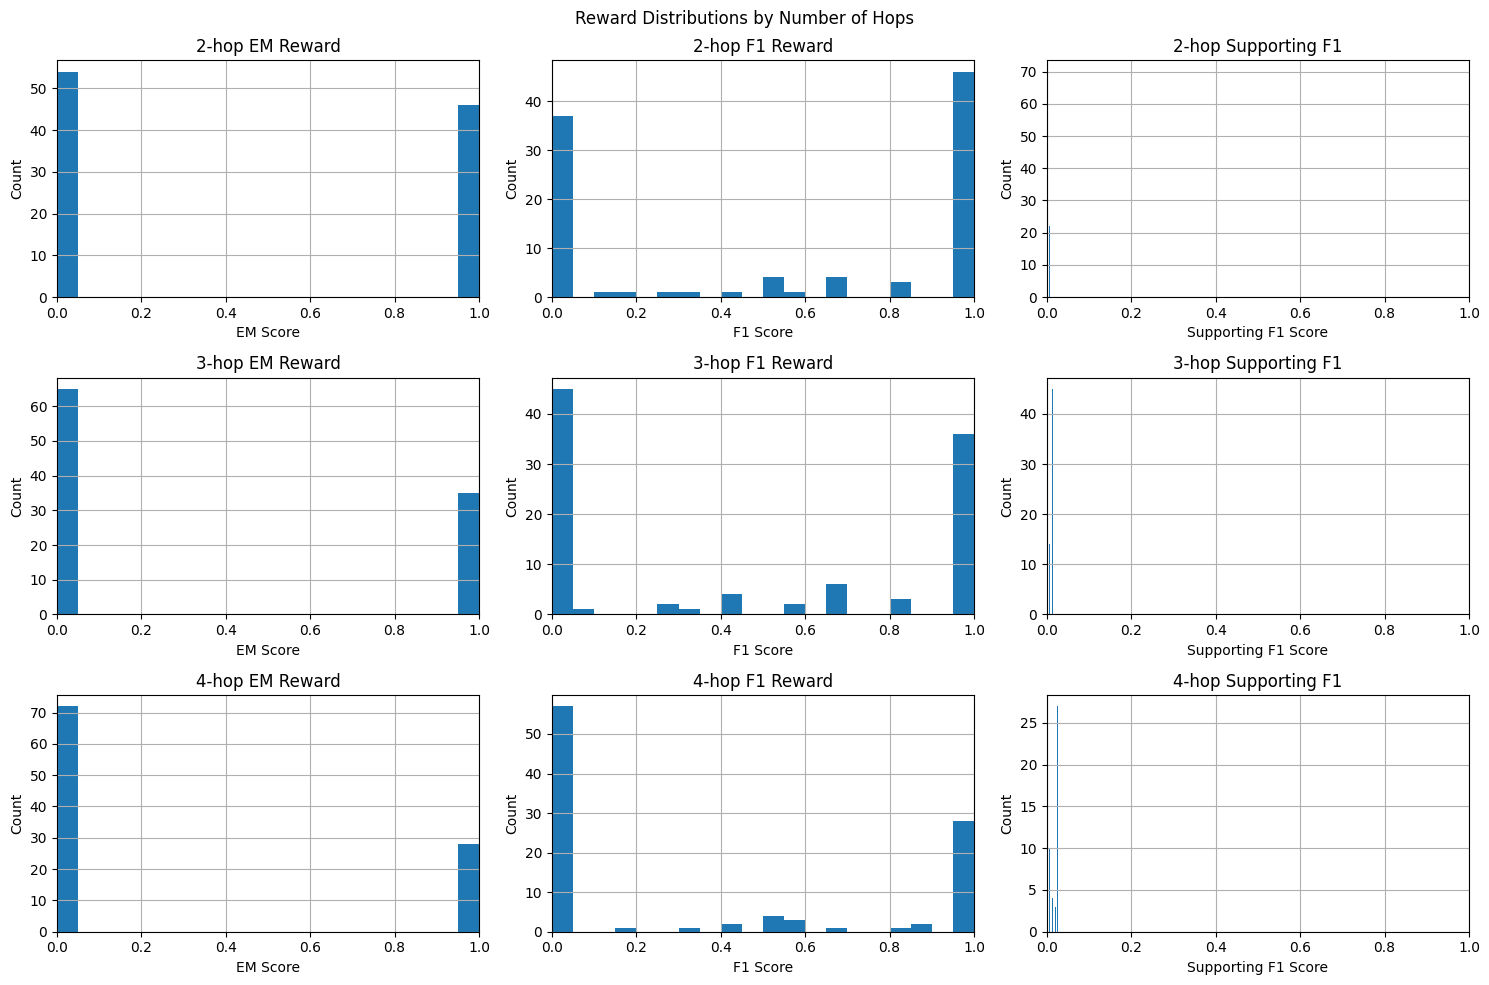

In [13]:
# Visualize rewards per n_hops
n_hops = sorted(df['n_hops'].unique())
fig, axes = plt.subplots(len(n_hops), 3, figsize=(15, 10))
fig.suptitle('Reward Distributions by Number of Hops')

for i, n_hop in enumerate(n_hops):
    subset = df[df['n_hops'] == n_hop]
    
    subset['reward.em'].hist(ax=axes[i,0], bins=20)
    axes[i,0].set_title(f'{n_hop}-hop EM Reward')
    axes[i,0].set_xlabel('EM Score')
    axes[i,0].set_ylabel('Count')
    axes[i,0].set_xlim(0, 1)
    
    subset['reward.f1'].hist(ax=axes[i,1], bins=20)
    axes[i,1].set_title(f'{n_hop}-hop F1 Reward')
    axes[i,1].set_xlabel('F1 Score')
    axes[i,1].set_ylabel('Count')
    axes[i,1].set_xlim(0, 1)
    
    subset['reward.supporting_f1'].hist(ax=axes[i,2], bins=20)
    axes[i,2].set_title(f'{n_hop}-hop Supporting F1')
    axes[i,2].set_xlabel('Supporting F1 Score')
    axes[i,2].set_ylabel('Count')
    axes[i,2].set_xlim(0, 1)


plt.tight_layout()
